In [11]:
import sys

sys.path.append('../')

In [12]:
from PID_copy.PIDAttitudeAviary import PIDAttitudeAviary
from PID_copy.DSLPIDPolicy import DSLPIDPolicy
import numpy as np
from ray.rllib.agents.ppo import PPOTorchPolicy

In [3]:
from PID_copy.OffPolicyTrainer import OffPolicyTrainer

env_creator = lambda _: PIDAttitudeAviary()

buffer_capacity = 50000
batch_size = 256

trainer = OffPolicyTrainer(env_creator, buffer_capacity, batch_size, behavior_policy=DSLPIDPolicy, rl_policy=PPOTorchPolicy)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


C:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [10]:
n_episodes = 1000
for i_eps in range(n_episodes):
    trainer.learn()
    if (i_eps%50) == 0:
        print("\rEpisode :", i_eps, "Results :", np.sum(trainer.evaluate()['rewards']))

Episode : 0 Results : -167.16122
Episode : 50 Results : -91.458755
Episode : 100 Results : -125.13771
Episode : 150 Results : -278.67752
Episode : 200 Results : -162.77686
Episode : 250 Results : -159.58273
Episode : 300 Results : -147.90645
Episode : 350 Results : -217.67705
Episode : 400 Results : -145.1323
Episode : 450 Results : -195.59247
Episode : 500 Results : -177.37524
Episode : 550 Results : -214.29443
Episode : 600 Results : -74.351105
Episode : 650 Results : -189.12146
Episode : 700 Results : -155.17729
Episode : 750 Results : -164.15768
Episode : 800 Results : -271.2687
Episode : 850 Results : -227.07805
Episode : 900 Results : -154.97409
Episode : 950 Results : -114.41323


In [13]:
import time 
from gym_pybullet_drones.utils.utils import sync
import matplotlib.pyplot as plt 

env = PIDAttitudeAviary(gui=False)
# policy = DSLPIDPolicy(env.observation_space, env.action_space, config={})
policy = trainer.eval_worker.get_policy()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


C:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


-4.521363656657965


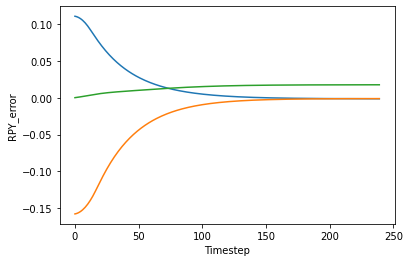

In [39]:
rpy_errs = []
cumm_reward = 0
obs = env.reset()
start = time.time()
for i in range(1*env.SIM_FREQ):
    action, _state, _dict = policy.compute_single_action(obs)
    obs, reward, done, info = env.step(action)
    cumm_reward += reward
    rpy_errs.append(info['rpy_err'])
    if env.GUI:
        if i%env.SIM_FREQ == 0:
            env.render()
            print(done)
        sync(i, start, env.TIMESTEP)
        if done:
            break

    
print(cumm_reward)
plt.plot(rpy_errs)
plt.xlabel("Timestep")
plt.ylabel("RPY_error")
plt.show()